In [1]:
import numpy as numpy
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('heart.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
num_col=df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
       'HeartDisease']]

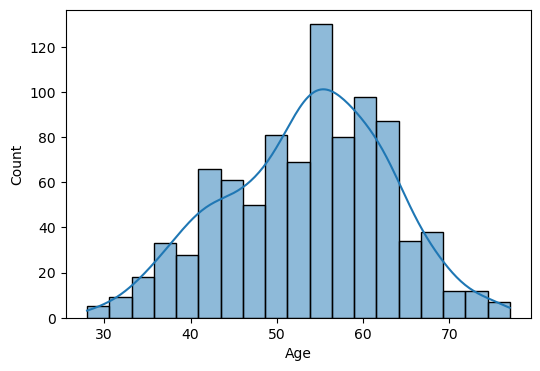

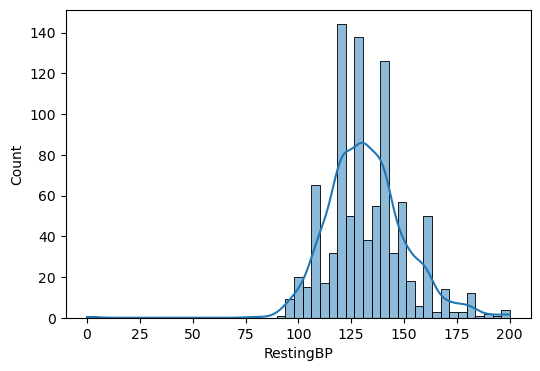

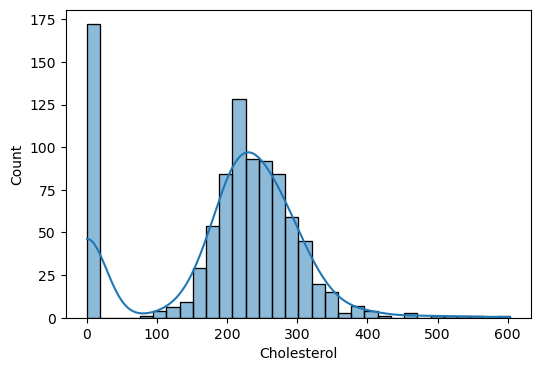

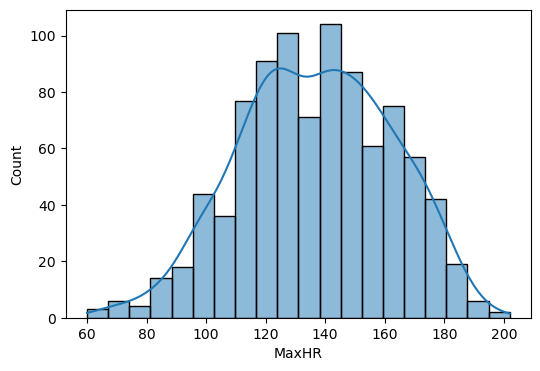

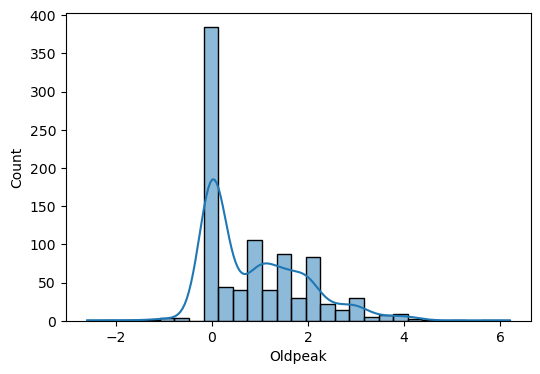

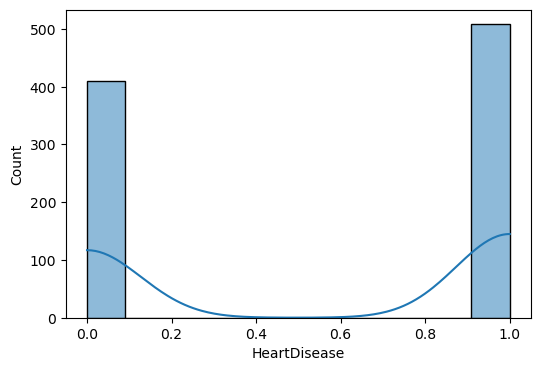

In [7]:
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)

In [8]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease', ylabel='count'>

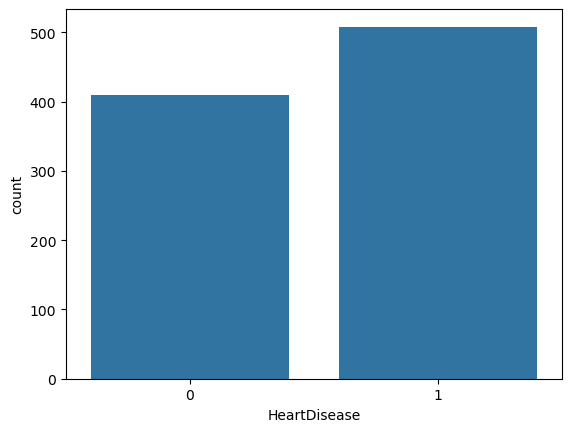

In [10]:
sns.countplot(x=df['HeartDisease'])

In [11]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

<Axes: xlabel='ChestPainType', ylabel='count'>

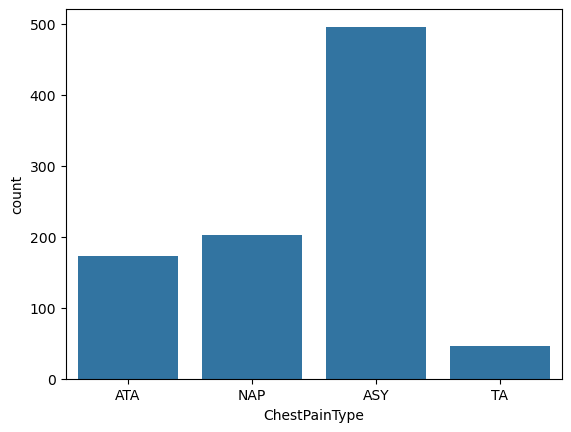

In [12]:
sns.countplot(x=df["ChestPainType"])

In [13]:
df = df[df['RestingBP'] >= 90]


In [14]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
101      1
117      1
192      1
129      1
164      1
Name: count, Length: 65, dtype: int64

<Axes: xlabel='RestingBP', ylabel='Count'>

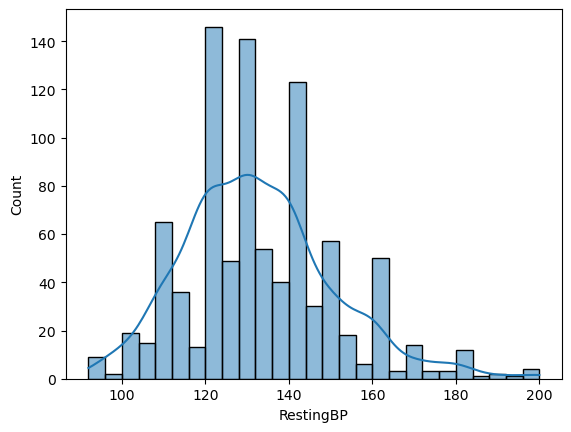

In [15]:
sns.histplot(df['RestingBP'],kde=True)

In [16]:
df["Cholesterol"].value_counts()

Cholesterol
0      170
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [17]:
df = df[df['Cholesterol'] >= 80]

<Axes: xlabel='Cholesterol', ylabel='Count'>

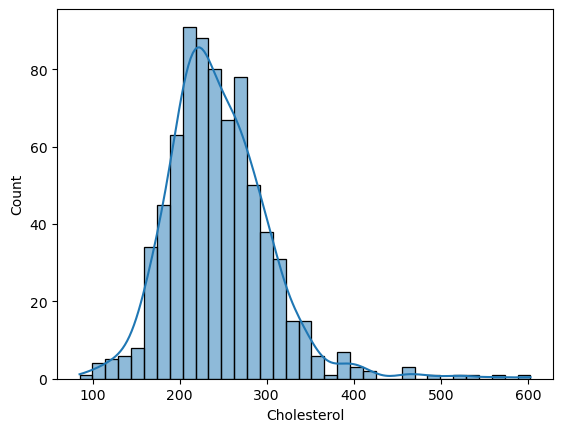

In [18]:
sns.histplot(df["Cholesterol"],kde=True)

<Axes: ylabel='Cholesterol'>

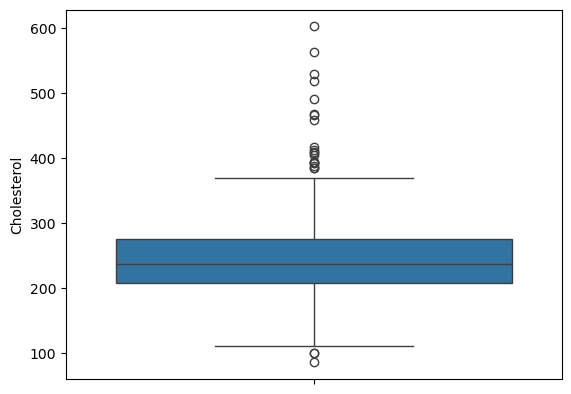

In [19]:
sns.boxplot(df["Cholesterol"])

<Axes: xlabel='FastingBS', ylabel='count'>

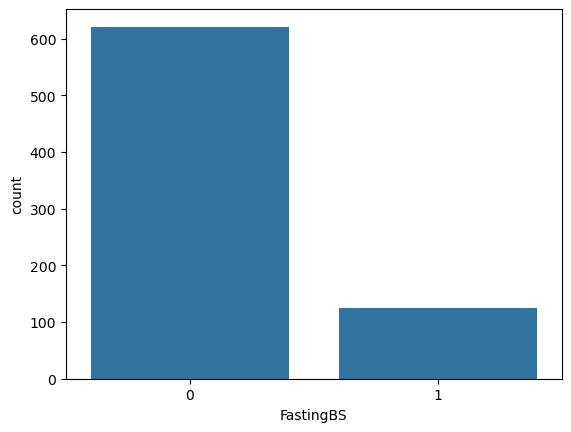

In [20]:
sns.countplot(x=df["FastingBS"])

<Axes: xlabel='RestingECG', ylabel='count'>

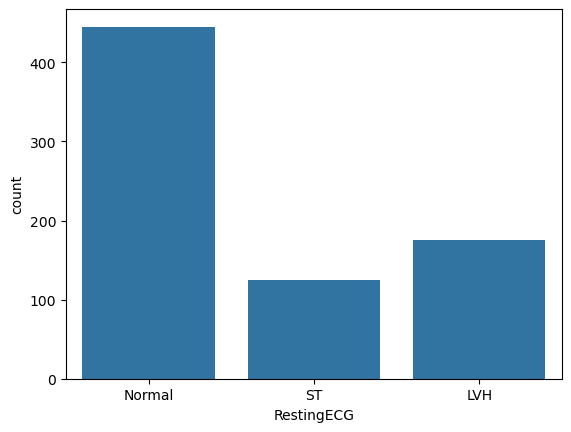

In [21]:
sns.countplot(x=df["RestingECG"])

In [22]:
df["RestingECG"].value_counts()

RestingECG
Normal    445
LVH       176
ST        125
Name: count, dtype: int64

<Axes: xlabel='ExerciseAngina', ylabel='count'>

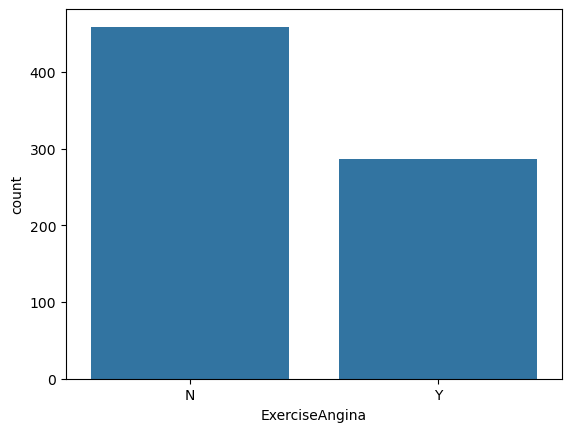

In [23]:
sns.countplot(x=df["ExerciseAngina"])

<Axes: xlabel='Oldpeak'>

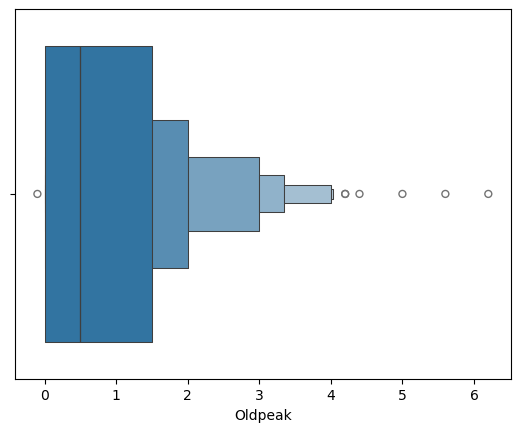

In [24]:
sns.boxenplot(x=df["Oldpeak"])

<Axes: >

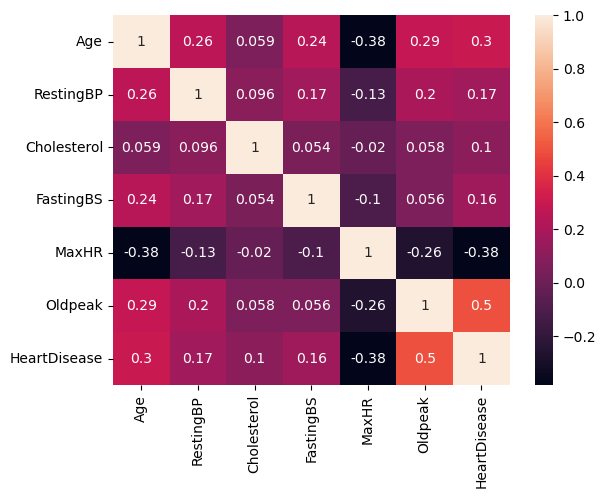

In [25]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Data Preprocessing

In [26]:
df_encode=pd.get_dummies(df)

In [27]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144,193,1,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130,236,0,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


In [28]:
df_encode=df_encode.astype(int)

In [29]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,141,3,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,115,1,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,174,0,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


In [30]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()

In [31]:
num_cols=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [32]:
df_encode[num_cols]=scale.fit_transform(df_encode[num_cols])

In [33]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.356073,0.403980,0.750494,0,1.296470,-0.729175,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.408656,1.561980,-1.093405,0,0.643613,0.268925,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.671879,-0.175019,0.648995,0,-1.722993,-0.729175,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.513925,0.288180,-0.518244,0,-1.314958,0.268925,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.117686,0.982980,-0.839657,0,-0.743708,-0.729175,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.829731,-1.333019,0.327582,0,-0.335672,0.268925,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,1.591446,0.635580,-0.873490,1,0.031560,2.265125,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,0.433492,-0.175019,-1.922314,0,-1.029333,0.268925,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,0.433492,-0.175019,-0.146081,0,1.378077,-0.729175,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


In [34]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score,f1_score,classification_report
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Support Vector Classifier
from sklearn.svm import SVC

# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier


In [36]:
X=df_encode.drop("HeartDisease",axis=1)

In [37]:
y=df_encode["HeartDisease"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [39]:
x_train_scaled=scale.fit_transform(X_train)
x_test_scaled=scale.fit_transform(X_test)

In [40]:
models={
    "logistic_regression":LogisticRegression(),
    "Gaussian":GaussianNB(),
    "DTC":DecisionTreeClassifier(),
    "SVM":SVC(),
    "KNN":KNeighborsClassifier()
}

In [41]:
results={}

In [42]:
for name, model in models.items():
    
    # Use scaled data for certain models
    if name in ["logistic_regression", "SVM", "KNN"]:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    
    print(f"Model: {name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-" * 50)

Model: logistic_regression
Accuracy: 0.9
Confusion Matrix:
 [[66  5]
 [10 69]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90        71
           1       0.93      0.87      0.90        79

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150

--------------------------------------------------
Model: Gaussian
Accuracy: 0.8866666666666667
Confusion Matrix:
 [[64  7]
 [10 69]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88        71
           1       0.91      0.87      0.89        79

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150

--------------------------------------------------
Model: DTC
Accuracy: 0.78666666666

In [43]:
import joblib
joblib.dump(models["SVM"],"SVM_Heart.pkl")
joblib.dump(scale,"scale.pkl")
joblib.dump(X.columns.tolist(),"columnns.pkl")

['columnns.pkl']

In [44]:
print(y.value_counts())


HeartDisease
0    390
1    356
Name: count, dtype: int64


In [46]:
sample = X.iloc[0:5]
print(model.predict(scale.transform(sample)))
print(y.iloc[0:5].values)


[0 0 0 1 0]
[0 1 0 1 0]
